# 🕊️ Verificacion con graficos de los perfiles de Twitter

## La variable `Y`

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Leemos el archivo final de la carpeta processed
df = pd.read_csv('../data/processed/twitter_profiles_cleaned.csv')

print(f"Dataset listo para graficar: {df.shape[0]} registros y {df.shape[1]} columnas.")

Grafico que muestra el balance entre perfiles reales y bots. Se observó que la falta de ubicación es un indicador clave de automatización, validando nuestro proceso de ingeniería de variables.

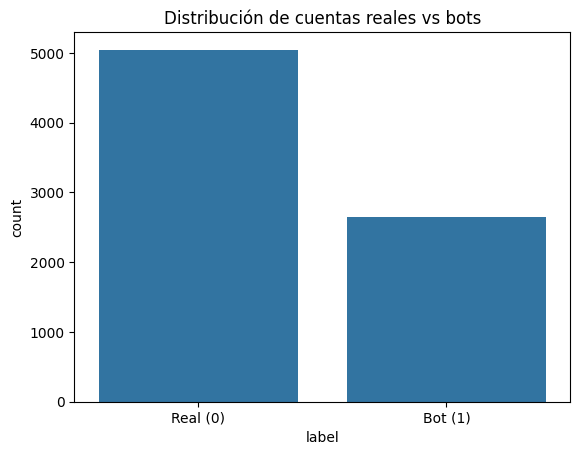

In [ ]:
#Grafico Distribución de bots vs reales
sns.countplot(data=df, x='label')
plt.title('Distribución de cuentas reales vs bots')
plt.xticks([0,1], ['Real (0)', 'Bot (1)'])
plt.show()

Comparativa de la audiencia mediante diagramas de caja. Las cuentas reales tienden a una mediana de seguidores significativamente mayor, mientras que los bots se concentran en rangos bajos, confirmando el comportamiento típico de cuentas de spam o recién creadas.

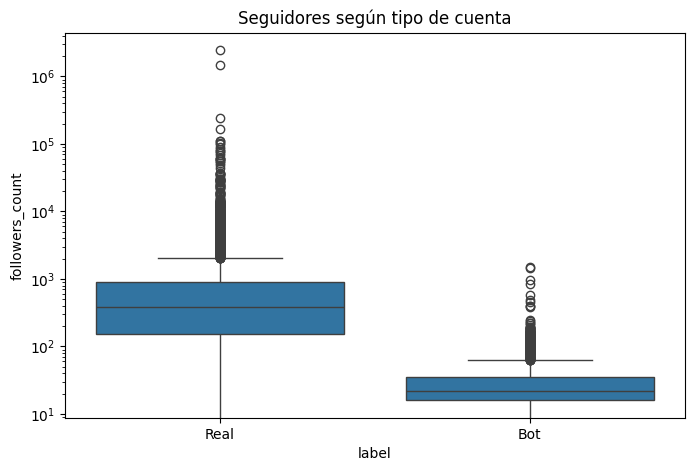

In [ ]:
#Grafico Seguidores según tipo de cuenta
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='followers_count')
plt.title('Seguidores según tipo de cuenta')
plt.xticks([0,1], ['Real', 'Bot'])
plt.yscale('log')   # importante por valores extremos
plt.show()

Se observa que los bots mantienen una cantidad de seguidos más uniforme y, en muchos casos, superior a su cantidad de seguidores. Este comportamiento busca forzar el "follow-back" para intentar ganar legitimidad de forma artificial.

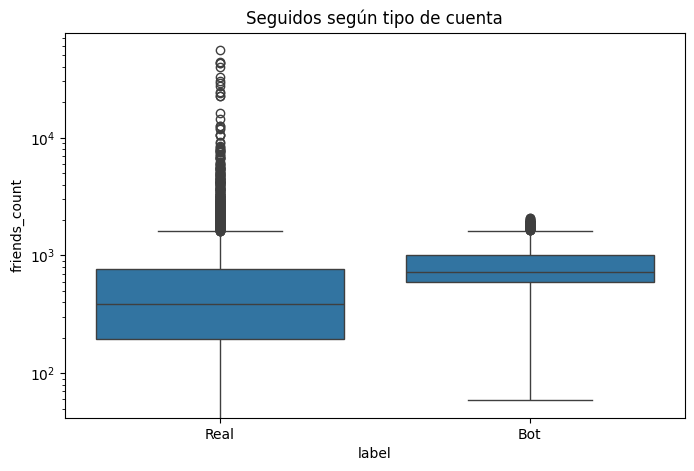

In [ ]:
#Grafico Seguidos (friends_count) por tipo
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='friends_count')
plt.title('Seguidos según tipo de cuenta')
plt.xticks([0,1], ['Real', 'Bot'])
plt.yscale('log')
plt.show()

Se observa que las cuentas reales mantienen niveles de actividad significativamente más altos y constantes. Al contrario, los bots presentan una actividad reducida o explosiva en periodos cortos, lo que refuerza la teoría de que son cuentas creadas para objetivos específicos y no para una interacción social genuina a largo plazo.

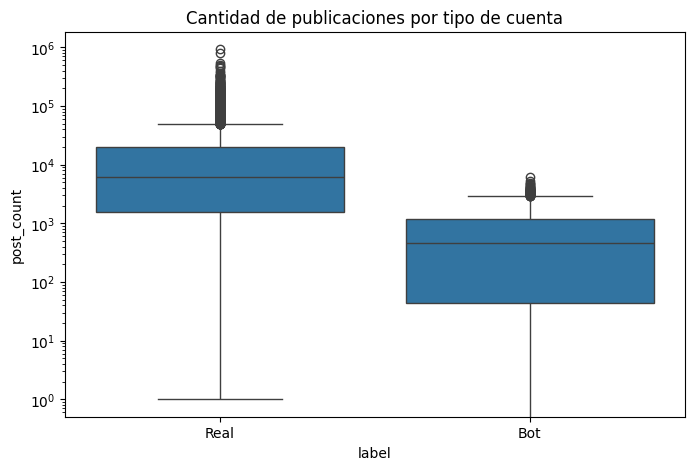

In [ ]:
#Grafico Cantidad de publicaciones
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='post_count')
plt.title('Cantidad de publicaciones por tipo de cuenta')
plt.xticks([0,1], ['Real', 'Bot'])
plt.yscale('log')
plt.show()

Se analiza la relación directa entre la presencia de ubicación y la naturaleza de la cuenta. Los resultados confirman que la omisión de este dato es un comportamiento casi exclusivo de los bots en este dataset, validando la variable 'has_location' como uno de los predictores más potentes para la detección de perfiles automatizados.

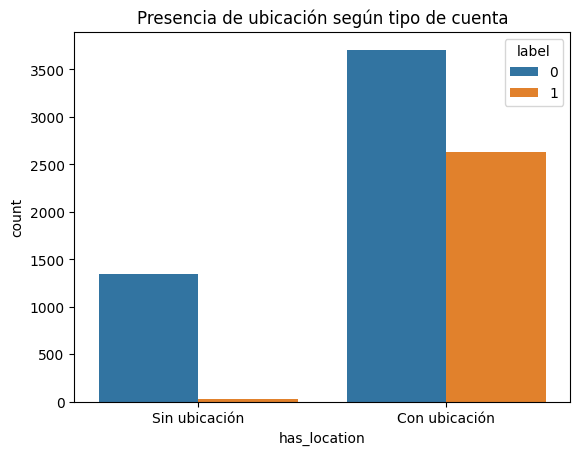

In [ ]:
from src.ingenieria_variable import generar_indicadores_perfil
df = generar_indicadores_perfil(df)

#Grafico ¿Tener ubicación ayuda a detectar bots?
sns.countplot(data=df, x='has_location', hue='label')
plt.title('Presencia de ubicación según tipo de cuenta')
plt.xticks([0,1], ['Sin ubicación', 'Con ubicación'])
plt.show()

Se contrasta la ubicación declarada con la base de datos de Nominatim. El gráfico revela que aunque algunos bots intentan simular una ubicación, la gran mayoría de las coordenadas falsas o incoherentes pertenecen a cuentas reales que usan texto creativo, mientras que los bots son filtrados exitosamente por su falta de datos verídicos.

In [ ]:
from src.validacion_geografica import procesar_geografia_completa
df = procesar_geografia_completa(df)

#Grafico Ubicación real vs falsa
sns.countplot(data=df, x='is_real_location', hue='label')
plt.title('Ubicación válida según tipo de cuenta')
plt.xticks([0,1], ['No válida', 'Válida'])
plt.show()

Se identifican los idiomas predominantes en el dataset. El gráfico muestra una concentración masiva en inglés (en), donde los bots tienen una presencia significativa. Por otro lado, idiomas como el italiano (it) muestran una base de usuarios reales muy alta, sugiriendo que la detección de bots debe considerar el contexto lingüístico del nicho analizado.

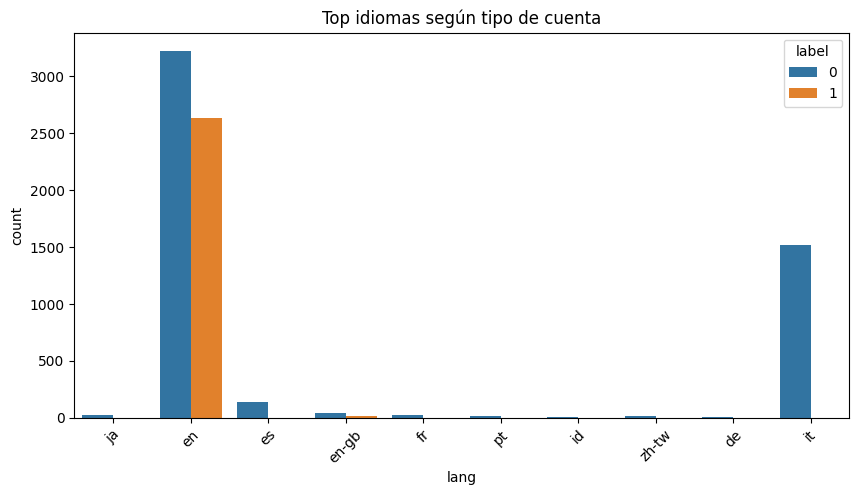

In [ ]:
#Grafico Idioma más frecuente
top_lang = df['lang'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.countplot(data=df[df['lang'].isin(top_lang)], x='lang', hue='label')
plt.title('Top idiomas según tipo de cuenta')
plt.xticks(rotation=45)
plt.show()

Se genera un mapa de calor para identificar dependencias entre variables cuantitativas. Este análisis permite detectar qué factores (como seguidores o cantidad de publicaciones) tienen una relación más fuerte con la clasificación de la cuenta (label), ayudando a priorizar las variables más influyentes para el modelo predictivo.

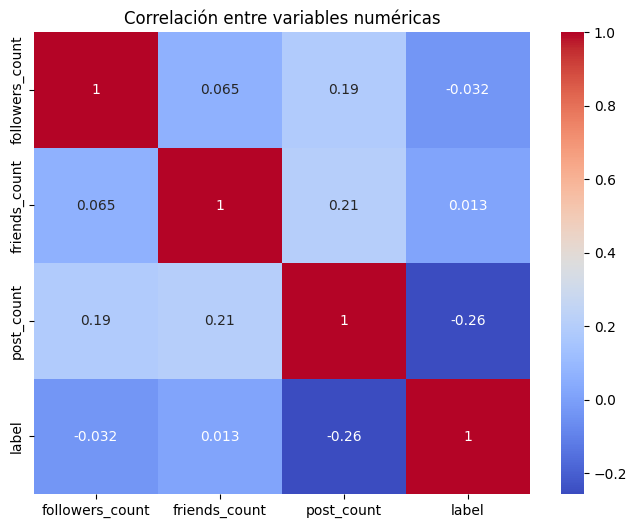

In [ ]:
#Grafico Correlación numérica
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()